# Multi-dataset: Differential Motif Analysis

This example demonstrates how to identify **motifs that are differentially enriched**
between two experimental conditions using `differential_analysis_dist`.

While motif enrichment (previous example) discovers motifs within each condition independently,
differential motif analysis directly compares motif frequencies between conditions using a
Mann-Whitney U test across FOVs, with FDR correction for multiple testing.

**Dataset:** CODEX spatial proteomics — CLR vs DII immune subtypes
**Key API:** `spatial_query_multi.differential_analysis_dist` and `spatial_query_multi.differential_analysis_knn`

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from SpatialQuery import spatial_query_multi

## Load Data & Initialize

In [3]:
DATA_DIR = "../data/codex_cancer"

adata = ad.read_h5ad(f"{DATA_DIR}/codex_data.h5ad")

adata

AnnData object with n_obs × n_vars = 258385 × 56
    obs: 'CellID', 'ClusterID', 'EventID', 'File Name', 'Region', 'TMA_AB', 'TMA_12', 'Index in File', 'groups', 'patients', 'spots', 'cell_id', 'size:size', 'HOECHST1_Cyc_1_ch_1', 'DRAQ5_Cyc_23_ch_4', 'Profile_Homogeneity:Fiter1', 'ClusterSize', 'ClusterName', 'neighborhood10', 'CD4+ICOS+', 'CD4+Ki67+', 'CD4+PD-1+', 'CD68+CD163+ICOS+', 'CD68+CD163+Ki67+', 'CD68+CD163+PD-1+', 'CD68+ICOS+', 'CD68+Ki67+', 'CD68+PD-1+', 'CD8+ICOS+', 'CD8+Ki67+', 'CD8+PD-1+', 'Treg-ICOS+', 'Treg-Ki67+', 'Treg-PD-1+', 'neighborhood number final', 'neighborhood name'
    var: 'marker_name', 'full_name', 'cell_type_annotation', 'cycle', 'channel'
    uns: 'data_source', 'groups_mapping', 'n_markers', 'technology'
    obsm: 'X_spatial_global', 'X_spatial_tile'

In [4]:
adata.X.max()

np.float32(54776.695)

Inspect `adata.obsm` for spatial coordinates, `adata.obs` for cell type labels and FOV identifiers, and `adata.var` for feature names. Then set the corresponding column names below.

In [5]:
# Assign immune subtype labels
adata.obs["state"] = "CLR"
adata.obs["state"][adata.obs["groups"] == 2] = "DII"

# Feature-wise z-score normalization for protein expression
adata.X = (adata.X - adata.X.mean(axis=0)) / adata.X.std(axis=0)


In [6]:
spatial_key = "X_spatial_tile"
label_key = "ClusterName"
feature_name = "marker_name"
fov_key = "File Name"

In [7]:
# Split data by FOV and immune subtype
clr_data = adata[adata.obs["state"] == "CLR"]
dii_data = adata[adata.obs["state"] == "DII"]

clr_datas = [clr_data[clr_data.obs[fov_key] == f] for f in clr_data.obs[fov_key].unique()]
dii_datas = [dii_data[dii_data.obs[fov_key] == f] for f in dii_data.obs[fov_key].unique()]

ds_names = ["CLR"] * len(clr_datas) + ["DII"] * len(dii_datas)
adata_fovs = clr_datas + dii_datas

print(f"CLR FOVs: {len(clr_datas)}, DII FOVs: {len(dii_datas)}")

CLR FOVs: 68, DII FOVs: 72


In [8]:
spm = spatial_query_multi(
    adatas=adata_fovs,
    datasets=ds_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=False,  # data is already z-score normalized
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0448
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 0.0311
build_gene_index is False. Using adata.X for gene expression analysis.

Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
... (548 lines omitted) ...
Scale factor: 0.0421
build_gene_index is False. Using adata.X for gene expression analysis.


## Run Differential Motif Analysis

`differential_analysis_dist` compares motif frequencies between two conditions across FOVs.
It first discovers all motifs present in either condition, then tests whether the per-FOV
support (frequency) of each motif differs significantly.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `datasets` | List of exactly two condition names to compare |
| `max_dist` | Neighborhood radius |
| `min_support` | Minimum support threshold for motif mining |

**Return value:** A dictionary with one key per condition. Each value is a DataFrame of
motifs that are significantly more frequent in that condition.

**Output columns:**

| Column | Description |
|--------|-------------|
| `itemsets` | The motif (frozenset of cell types) |
| `support_<cond1>_mean` | Mean frequency across FOVs in condition 1 |
| `support_<cond2>_mean` | Mean frequency across FOVs in condition 2 |
| `adj-pval` | FDR-adjusted p-value (Mann-Whitney U) |

In [9]:
anchor_ct = "B cells"
max_dist = 5
min_support = 0.5
clr = "CLR"
dii = "DII"

diff_motif = spm.differential_analysis_dist(
    ct=anchor_ct,
    datasets=[clr, dii],
    max_dist=max_dist,
    min_support=min_support,
)

Discovered 501 motifs across the datasets for differential analysis.


## Inspect Results

Check which motifs are enriched in each condition.

In [10]:
print(f"Motifs enriched in {clr}: {len(diff_motif[clr])}")
diff_motif[clr]

Motifs enriched in CLR: 0


,itemsets,support_CLR_mean,support_DII_mean,adj-pval


In [11]:
print(f"Motifs enriched in {dii}: {len(diff_motif[dii])}")
diff_motif[dii]

Motifs enriched in DII: 4


,itemsets,support_CLR_mean,support_DII_mean,adj-pval
0,"(CD8+ T cells, Tregs, smooth muscle)",0.050989,0.146879,0.003753
1,"(CD68+CD163+ macrophages, CD8+ T cells, Tregs,...",0.048059,0.138878,0.003753
2,"(CD68+CD163+ macrophages, Tregs, granulocytes,...",0.041341,0.098820,0.019282
3,"(CD68+CD163+ macrophages, Tregs)",0.159009,0.302162,0.025271


### Validate Differential Motifs with Enrichment Analysis

A motif being **differential** (more frequent in one condition) does not guarantee it is
**enriched** (significantly over-represented compared to random expectation) in that condition.
To confirm, run `motif_enrichment_dist` on the differential motifs within the condition
where they are more frequent.

In [12]:
for ds in [clr, dii]:
    df = diff_motif[ds]
    if len(df) == 0:
        print(f"{ds}: No differential motifs to validate.\n")
        continue

    # Extract motif lists from the differential results
    motif_lists = [list(m) for m in df["itemsets"]]

    enrich_result = spm.motif_enrichment_dist(
        ct=anchor_ct,
        motifs=motif_lists,
        dataset=ds,
        max_dist=max_dist,
        min_support=min_support,
    )

    n_enriched = enrich_result["if_significant"].sum()
    print(f"{ds}: {len(df)} differential motifs → {n_enriched} also enriched")
    display(enrich_result)

CLR: No differential motifs to validate.

DII: 4 differential motifs → 4 also enriched


,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant
0,B cells,"[CD8+ T cells, Tregs, smooth muscle]",524,2774,14684,276.488664,4.919139e-47,1.967656e-46,True
1,B cells,"[CD68+CD163+ macrophages, CD8+ T cells, Tregs,...",390,2774,13610,256.266053,4.003156e-17,8.006311e-17,True
2,B cells,"[CD68+CD163+ macrophages, Tregs]",758,2774,33568,632.060167,7.534204e-09,1.004561e-08,True
3,B cells,"[CD68+CD163+ macrophages, Tregs, granulocytes,...",269,2774,12513,235.610369,1.094891e-02,1.094891e-02,True


## KNN-based Differential Motif Analysis

The KNN variant (`differential_analysis_knn`) defines neighborhoods by the *k* nearest neighbors
rather than a fixed radius. This can provide complementary results, especially when cell density varies.

In [13]:
k = 30

diff_motif_knn = spm.differential_analysis_knn(
    ct=anchor_ct,
    datasets=[clr, dii],
    k=k,
    min_support=min_support,
)

for ds in [clr, dii]:
    print(f"KNN differential motifs in {ds}: {len(diff_motif_knn[ds])}")

KNN differential motifs in CLR: 0
KNN differential motifs in DII: 4


In [14]:
diff_motif_knn[clr]

,itemsets,support_CLR_mean,support_DII_mean,adj-pval


In [15]:
diff_motif_knn[dii]

,itemsets,support_CLR_mean,support_DII_mean,adj-pval
0,"(CD68+CD163+ macrophages, Tregs, smooth muscle)",0.058319,0.179174,0.023677
1,"(CD4+ T cells CD45RO+, CD68+CD163+ macrophages...",0.107069,0.245905,0.023677
2,"(CD4+ T cells CD45RO+, CD68+CD163+ macrophages...",0.032668,0.118155,0.023677
3,"(CD4+ T cells CD45RO+, CD68+CD163+ macrophages...",0.093074,0.211532,0.030161


### Validate KNN Differential Motifs with Enrichment Analysis

Same validation as above, but using `motif_enrichment_knn` to match the KNN neighborhood
definition used in differential analysis.

In [16]:
for ds in [clr, dii]:
    df = diff_motif_knn[ds]
    if len(df) == 0:
        print(f"{ds}: No differential motifs to validate.\n")
        continue

    motif_lists = [list(m) for m in df["itemsets"]]

    enrich_result = spm.motif_enrichment_knn(
        ct=anchor_ct,
        motifs=motif_lists,
        dataset=ds,
        k=k,
    )

    n_enriched = enrich_result["if_significant"].sum()
    print(f"{ds}: {len(df)} differential motifs → {n_enriched} also enriched")
    display(enrich_result)

CLR: No differential motifs to validate.

DII: 4 differential motifs → 4 also enriched


,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant
0,B cells,"[CD4+ T cells CD45RO+, CD68+CD163+ macrophages...",535,2774,24457,460.506896,0.000075,0.000171,True
1,B cells,"[CD4+ T cells CD45RO+, CD68+CD163+ macrophages...",256,2774,10846,204.222014,0.000102,0.000171,True
2,B cells,"[CD4+ T cells CD45RO+, CD68+CD163+ macrophages...",438,2774,19761,372.084752,0.000128,0.000171,True
3,B cells,"[CD68+CD163+ macrophages, Tregs, smooth muscle]",435,2774,20771,391.102292,0.007858,0.007858,True


## Built-in Visualization

SpatialQuery provides `plot_differential_pattern_heatmap` for quick visualization of
differential motif results.

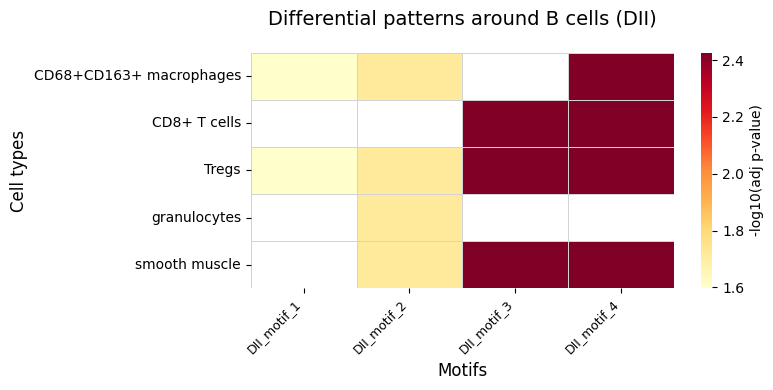

In [18]:
from SpatialQuery.plotting import plot_differential_pattern_heatmap

plot_differential_pattern_heatmap(diff_motif=diff_motif, ct=anchor_ct)

## Custom Visualization

For more control over the layout, you can build custom heatmaps from the result DataFrame.
Below we create side-by-side fold change and significance heatmaps.

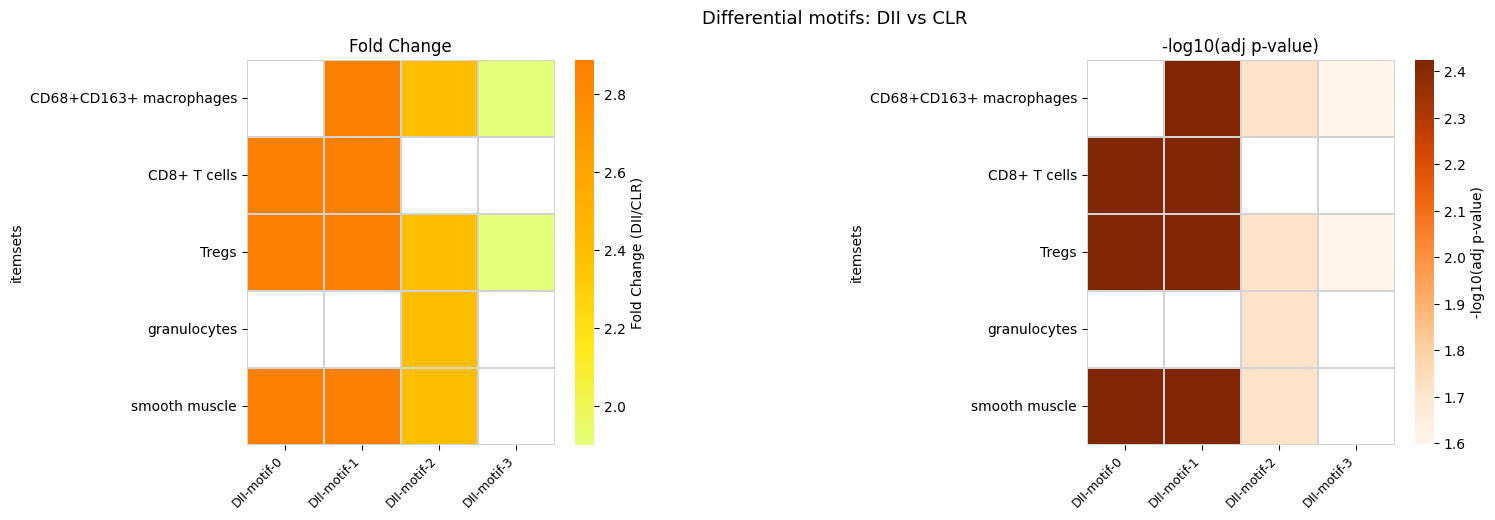

In [19]:
diff_motif[clr] = diff_motif[clr].copy()
diff_motif[dii] = diff_motif[dii].copy()
diff_motif[clr]["group"] = clr
diff_motif[dii]["group"] = dii

enrich = pd.concat([diff_motif[dii], diff_motif[clr]], axis=0)
enrich["fold_change"] = enrich[f"support_{dii}_mean"] / enrich[f"support_{clr}_mean"]
enrich["motif_group"] = enrich["group"] + "_motif_" + enrich.index.astype(str)
col_order = enrich["motif_group"].tolist()

enrich_expanded = enrich.explode("itemsets")

heatmap_fc = enrich_expanded.pivot_table(
    index="itemsets", columns="motif_group", values="fold_change",
)[col_order]

heatmap_pval = enrich_expanded.pivot_table(
    index="itemsets", columns="motif_group", values="adj-pval",
)
heatmap_pval = -np.log10(heatmap_pval)[col_order]

col_labels = [c.replace("_", "-") for c in col_order]
heatmap_fc.columns = col_labels
heatmap_pval.columns = col_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"wspace": 1.1})

sns.heatmap(
    heatmap_fc, cmap="Wistia", linewidths=0.1, linecolor="lightgrey",
    square=True, cbar_kws={"label": "Fold Change (DII/CLR)"}, ax=ax1,
)
ax1.set_title("Fold Change")
ax1.set_xlabel("")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=9)

sns.heatmap(
    heatmap_pval, cmap="Oranges", linewidths=0.1, linecolor="lightgrey",
    square=True, cbar_kws={"label": "-log10(adj p-value)"}, ax=ax2,
)
ax2.set_title("-log10(adj p-value)")
ax2.set_xlabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=9)

fig.suptitle(f"Differential motifs: {dii} vs {clr}", fontsize=13)
plt.tight_layout()
plt.show()